In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("Watera.csv")

df.head()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0


## Handling Null Values

In [ ]:
df.dropna()

In [ ]:
df.dropna(axis=1)

In [ ]:
df['ph'].mean()

In [3]:
df['ph'].fillna(value=7)
df['ph'].fillna(df['ph'].mean())

0        7.14
1        6.41
2        6.29
3        7.39
4        6.31
         ... 
99995    5.41
99996    8.43
99997    5.79
99998    7.03
99999    7.68
Name: ph, Length: 100000, dtype: float64

In [ ]:
df['ph'].fillna(df['ph'].median())

In [ ]:
df['ph'].fillna(df['ph'].mode())

In [4]:
df['sulphate'].fillna(method='ffill')

KeyError: 'sulphate'

In [ ]:
df['sulphate'].fillna(method='bfill')

In [2]:
df.loc[df['conductivity'].isnull(),'conductivity']=df['conductivity'].median()

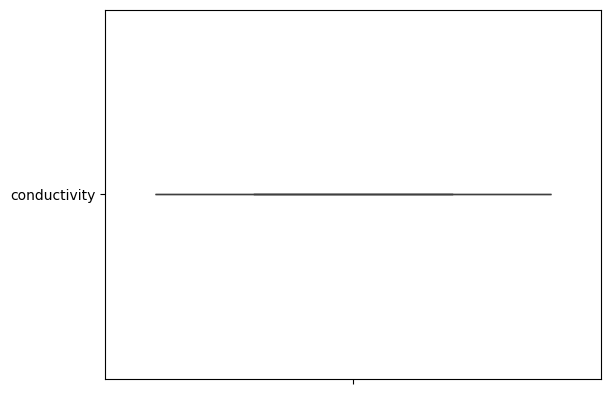

In [7]:
sns.boxplot('conductivity')

plt.show()

In [4]:
Q1 = df['sulfate'].quantile(0.25)
Q3 = df['sulfate'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['sulfate'] < lower) | (df['sulfate'] > upper)]
print(f"IQR outliers: {len(outliers_iqr)} rows")
print(f"Lower bound: {lower:.1f}, Upper: {upper:.1f}")/m

IQR outliers: 3801 rows
Lower bound: -159.9, Upper: 634.3


NameError: name 'm' is not defined

In [10]:
from scipy import stats
z_scores = np.abs(stats.zscore(df['conductivity']))
outliers_z = df[z_scores > 3]
print(f"Z-Score outliers: {len(outliers_z)} rows")

── HANDLING OPTIONS ─────────────────────────────────
Option A: Remove outlier rows (only if few)
df_clean = df[~((df['conductivity'] < lower) | (df['conductivity'] > upper))]

Option B: Cap/clip to max allowed value (Winsorizing)
df['conductivity'] = df['conductivity'].clip(lower, upper)

Option C: Log transform (great for skewed data!)
df['conductivity_log'] = np.log1p(df['conductivity'])

print("\nAfter clipping:")
print(df['conductivity'].describe())

SyntaxError: invalid character '─' (U+2500) (4089548866.py, line 6)

## Handling outliers

In [5]:
df=df[(df['conductivity']>=lower)&(df['conductivity']<=upper)]

In [9]:
# caping classic outliers-caping(winsorization)techinque
df['conductivity']=np.where(df['conductivity']>upper,upper,df['conductivity'])
df['conductivity']=np.where(df['conductivity']<lower,lower,df['conductivity'])

In [10]:
!pip install feature_engine

In [14]:
from  feature_engine.outliers import Winsorizer

In [16]:
winsor=Winsorizer(capping_method='iqr',tail='both',fold=1.5)
df['conductivity']=winsor.fit_transform(df[['conductivity']])

## Duplicates 

In [17]:
df.duplicated()

0        False
1        False
4        False
5        False
6        False
         ...  
99987    False
99991    False
99993    False
99994    False
99995    False
Length: 21849, dtype: bool

In [18]:
df.duplicated().sum()

np.int64(0)

## Handling Duplicates

In [19]:
df.drop_duplicates()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0
5,5.79,377.09,252.26,3.02,152.95,77.31,11.21,197.56,1.50,0
6,5.74,209.58,185.39,0.22,104.71,398.26,8.44,38.83,1.14,0
...,...,...,...,...,...,...,...,...,...,...
99987,6.69,271.44,87.57,1.22,346.26,533.61,13.06,88.15,2.87,0
99991,5.07,180.95,667.19,1.12,54.63,211.77,10.92,123.12,4.95,0
99993,8.07,350.14,359.93,0.42,689.91,601.68,11.73,47.21,5.38,0
99994,8.18,493.91,159.19,4.09,540.15,564.67,1.23,80.90,0.83,0


## Feature Scaling

## . Min_Max scalar
## .Satndard Scalar
## .Robust Scalar

In [22]:
from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler() #intilizing
df[['tds']]=Scalar.fit_transform(df[['tds']])

In [23]:
df.head(2)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,1.142947,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,0.227808,3.93,313.10,153.36,9.92,20.69,2.07,0


In [26]:
from sklearn.preprocessing import MinMaxScaler
Scalar=MinMaxScaler()
df[['tds']]=Scalar.fit_transform(df[['tds']])

In [27]:
df.head(2)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,0.558425,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,0.352561,3.93,313.10,153.36,9.92,20.69,2.07,0


## Robust Scaler

In [28]:
from sklearn.preprocessing import RobustScaler
Scalar=RobustScaler()
df[['hardness']]=Scalar.fit_transform(df[['hardness']])

In [29]:
df.head(2)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,0.700306,0.558425,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,-0.119621,0.352561,3.93,313.10,153.36,9.92,20.69,2.07,0
